In [3]:
%pip install timm

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 41.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 62.3 MB/s  0:00:00
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [timm]2m 9/10 [timm]ngface_hub]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights
import timm

# Set device (GPU, MPS, or CPU)
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")

# Load EfficientNet-B0
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=10
)

# Move the model to the chosen device
model = model.to(device)

print(model)

/opt/homebrew/Caskroom/miniforge/base/envs/AI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bi

In [5]:
train_dir = "data/train"
test_dir = "data/val"

In [6]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torch import nn
# Define transformations
transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224,
0.225])
])

# Load dataset
train_dataset = datasets.ImageFolder(root=train_dir,
transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir,
transform=transform)
# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=32,
shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32,
shuffle=False)

In [7]:
from torchinfo import summary
# Ensure model is on the correct device
model.to(device)
# Print model summary
summary(model=model,input_size=(32, 3, 224, 224),
col_names=["input_size", "output_size", "num_params", "trainable"],
col_width=20,
row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                        [32, 3, 224, 224]    [32, 10]             --                   True
├─Conv2d (conv_stem)                               [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
├─BatchNormAct2d (bn1)                             [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    └─Identity (drop)                             [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─SiLU (act)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
├─Sequential (blocks)                              [32, 32, 112, 112]   [32, 320, 7, 7]      --                   True
│    └─Sequential (0)                              [32, 32, 112, 112]   [32, 16, 112, 112]   --                   True
│    │    └─DepthwiseSeparableConv (0)         

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,
weight_decay=1e-4)

In [9]:
from trainNN import train
# Train the model for 5 epochs
results = train(
model=model,
train_dataloader=train_dataloader,
test_dataloader=test_dataloader,
optimizer=optimizer,
loss_fn=loss_fn,
epochs=5,
device=device
)

Epochs:  20%|██        | 1/5 [05:23<21:32, 323.01s/it]

Epoch: 1 | train_loss: 0.3994 | train_acc: 0.8946 | test_loss: 0.2254 | test_acc: 0.9324
[INFO] New best model saved to best_model.pth with test_acc: 0.9324


Epochs:  40%|████      | 2/5 [11:18<17:06, 342.25s/it]

Epoch: 2 | train_loss: 0.2073 | train_acc: 0.9374 | test_loss: 0.1776 | test_acc: 0.9435
[INFO] New best model saved to best_model.pth with test_acc: 0.9435


Epochs:  60%|██████    | 3/5 [17:42<12:02, 361.39s/it]

Epoch: 3 | train_loss: 0.1680 | train_acc: 0.9506 | test_loss: 0.2468 | test_acc: 0.9375


Epochs:  80%|████████  | 4/5 [23:51<06:04, 364.27s/it]

Epoch: 4 | train_loss: 0.1451 | train_acc: 0.9566 | test_loss: 0.4457 | test_acc: 0.9045


Epochs: 100%|██████████| 5/5 [30:27<00:00, 365.46s/it]

Epoch: 5 | train_loss: 0.0881 | train_acc: 0.9742 | test_loss: 0.3125 | test_acc: 0.9196


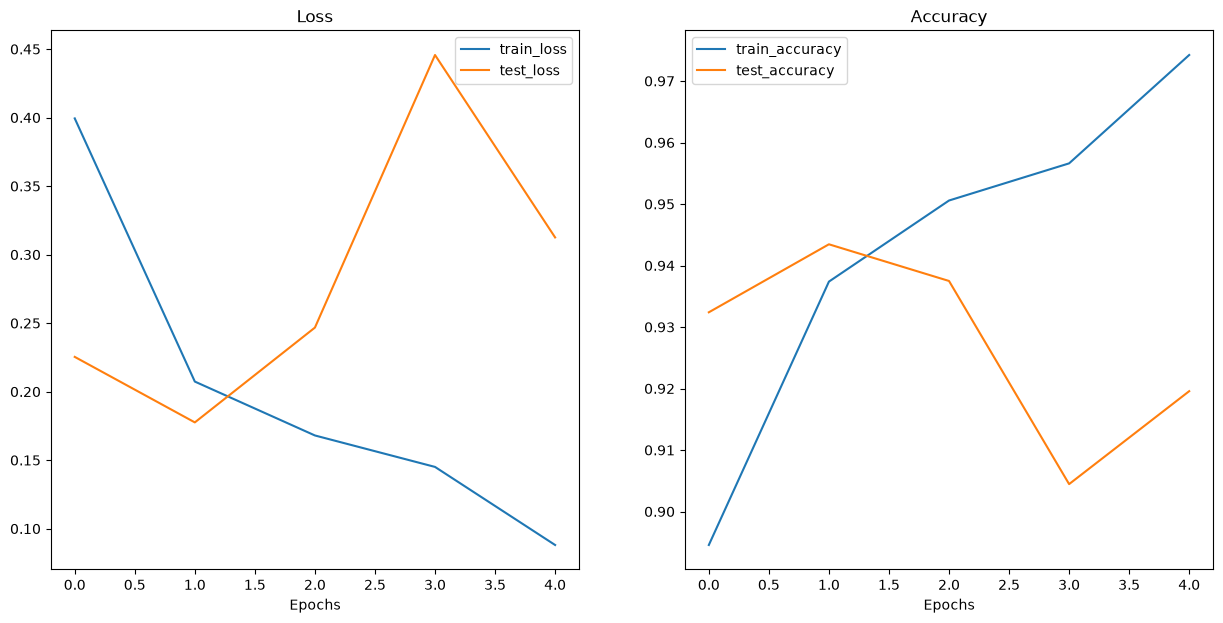

In [10]:
from helper_functions import plot_loss_curves
plot_loss_curves(results)